#                     Multidisciplinary UAV Wing Design Tool

## Overview

This project implements a conceptual UAV wing sizing framework integrating:

- XFOIL-based 2D airfoil aerodynamics  
- 3D induced drag correction (finite wing effects)  
- Multi-flight-condition constraints (Cruise + Loiter)  
- Structural stress and tip deflection limits  
- Tapered wing geometry  
- Mass minimization under constraints  

The goal is to find a wing that is as light as possible while still flying safely and efficiently for a given UAV mission.

---

## Design Variables

The optimization explores:

- **Span** $b$: overall wing span (m)  
- **Root chord** $c_r$: chord length at the wing root (m)  
- **Taper ratio** $\lambda = c_t / c_r$: ratio of tip chord to root chord  
- **Thickness ratio** $t/c$: airfoil thickness as a fraction of chord  

These variables together define a tapered wing with a NACA 24xx airfoil.

---

## Constraints

### Aerodynamic

- Lift ≥ required lift in each flight condition (Cruise and Loiter)  
- Stall margin enforced using a maximum allowable lift coefficient  

### Structural

- Maximum bending stress at the root ≤ allowable stress / safety factor  
- Tip deflection ≤ 10% of the span  

### Performance

- Induced drag from finite wing effects is included  
- Trade-off between low mass and good L/D is visible in the results  

---

## Methodology

The optimization process follows these steps:

1. Generate candidate wing geometries using:
   - Span
   - Root chord
   - Taper ratio
   - Thickness ratio

2. For each candidate:
   - Compute wing area and aspect ratio.
   - Evaluate airfoil performance using XFOIL.
   - Apply induced drag correction for finite-wing effects.

3. Enforce aerodynamic constraints:
   - Lift requirement in cruise and loiter.
   - Stall margin enforcement.

4. Evaluate structural constraints:
   - Root bending stress limit.
   - Tip deflection limit.

5. Select the minimum-mass design among all feasible candidates.

## Governing Equations

### Lift

L = 0.5 * rho * V^2 * S * CL

### Induced Drag

CD_induced = CL^2 / (pi * AR * e)

### Total Drag

CD_total = CD_profile + CD_induced

### Root Bending Stress

sigma = M_root / Z

### Tip Deflection (Cantilever Beam)

delta = w * L^4 / (8 * E * I)

## Engineering Insights

From the optimization results, several observations can be made:

- Increasing span improves aerodynamic efficiency (higher aspect ratio), but increases bending stress and deflection.
- Thicker airfoils improve structural stiffness but may reduce aerodynamic efficiency.
- The optimal design represents a balance between structural stiffness and aerodynamic performance.
- Multi-condition constraints (Cruise + Loiter) significantly influence optimal geometry.

In [3]:
import numpy as np
import subprocess
import os
import matplotlib.pyplot as plt

# ============================================
# GLOBAL CONFIG / DEFAULTS
# (mission values will be set in optimize_wing)
# ============================================

# Air + material properties (you can tweak these)
RHO = 1.225          # air density (kg/m^3)
SIGMA_ALLOW = 200e6  # allowable stress (Pa)
SF_STRUCT = 1.5      # safety factor on stress
E_MAT = 30e9         # Young's modulus (Pa)
RHO_MAT = 300.0      # structural density (kg/m^3)

# Structural constraint: max tip deflection = % of span
DEFLECTION_LIMIT_RATIO = 0.10  # 10%

# Aero constants
CL_MAX_ASSUMED = 1.4  # rough CL_max for stall check
E_OSWALD = 0.8        # Oswald efficiency factor
NU = 1.5e-5           # kinematic viscosity (m^2/s)

# Mission (will be overwritten in optimize_wing)
UAV_MASS_KG = 3.0
V_CRUISE = 18.0
V_LOITER = 14.0
W = UAV_MASS_KG * 9.81

FLIGHT_CONDITIONS = []  # filled in optimize_wing

# XFOIL executable path – adjust if needed
XFOIL_PATH = r"C:\xfoil\xfoil.exe"
XFOIL_WORKDIR = os.path.dirname(XFOIL_PATH)


# ============================================
# XFOIL HELPERS
# ============================================

def run_xfoil_single(airfoil_code, Re, alpha_deg):
    """Run XFOIL once at a single AoA. Returns CL, CD_profile, ok."""
    cmd_file = os.path.join(XFOIL_WORKDIR, "xfoil_cmd.in")
    polar_file = os.path.join(XFOIL_WORKDIR, "polar.dat")

    if os.path.exists(polar_file):
        os.remove(polar_file)

    script = f"""\
NACA {airfoil_code}
PANE
PLOP
G F

OPER
VISC {Re:.0f}
ITER 200
PACC
{os.path.basename(polar_file)}

ALFA {alpha_deg:.3f}
PACC
QUIT
"""

    with open(cmd_file, "w") as f:
        f.write(script)

    try:
        subprocess.run(
            [XFOIL_PATH],
            stdin=open(cmd_file, "r"),
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            cwd=XFOIL_WORKDIR,
            timeout=15
        )
    except Exception:
        return 0.0, 0.0, False

    if not os.path.exists(polar_file):
        return 0.0, 0.0, False

    CL = None
    CD = None
    with open(polar_file, "r") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#") or line.lower().startswith("alpha"):
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    CL = float(parts[1])
                    CD = float(parts[2])
                except ValueError:
                    continue

    if CL is None or CD is None:
        return 0.0, 0.0, False

    return CL, CD, True


def run_xfoil_polar_naca(airfoil_code, Re, alpha_start, alpha_end, alpha_step):
    """Full AoA sweep for drag polar (used only for best design)."""
    cmd_file = os.path.join(XFOIL_WORKDIR, "xfoil_cmd.in")
    polar_file = os.path.join(XFOIL_WORKDIR, "polar.dat")

    if os.path.exists(polar_file):
        os.remove(polar_file)

    script = f"""\
NACA {airfoil_code}
PANE
PLOP
G F

OPER
VISC {Re:.0f}
ITER 200
PACC
{os.path.basename(polar_file)}

ASEQ {alpha_start:.2f} {alpha_end:.2f} {alpha_step:.2f}
PACC
QUIT
"""

    with open(cmd_file, "w") as f:
        f.write(script)

    try:
        subprocess.run(
            [XFOIL_PATH],
            stdin=open(cmd_file, "r"),
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            cwd=XFOIL_WORKDIR,
            timeout=20
        )
    except Exception:
        return None, None, None, False

    if not os.path.exists(polar_file):
        return None, None, None, False

    alphas, CLs, CDs = [], [], []
    with open(polar_file, "r") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#") or line.lower().startswith("alpha"):
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    alphas.append(float(parts[0]))
                    CLs.append(float(parts[1]))
                    CDs.append(float(parts[2]))
                except ValueError:
                    continue

    if len(alphas) == 0:
        return None, None, None, False

    n = min(len(alphas), len(CLs), len(CDs))
    return np.array(alphas[:n]), np.array(CLs[:n]), np.array(CDs[:n]), True


# ============================================
# MODELS
# ============================================

def aero_for_conditions(S, AR, c_ref, t_rel):
    """
    Aero for all flight conditions (single-α XFOIL calls).
    Adds 3D induced drag.
    """
    t_percent = int(round(t_rel * 100.0))
    t_percent = max(8, min(20, t_percent))
    airfoil_code = f"24{t_percent:02d}"

    results = []
    all_ok = True

    for cond in FLIGHT_CONDITIONS:
        V = cond["V"]
        alpha_deg = cond["alpha_deg"]
        lift_sf = cond["lift_sf"]

        Re = V * c_ref / NU
        CL, CD_prof, ok = run_xfoil_single(airfoil_code, Re, alpha_deg)

        if not ok:
            all_ok = False
            results.append({
                "name": cond["name"],
                "ok": False,
                "stall_ok": False,
                "lift_ok": False,
                "CL": 0.0,
                "CD_total": 0.0,
                "Lift": 0.0,
                "Drag": 0.0,
                "V": V,
                "alpha_deg": alpha_deg,
                "lift_required": lift_sf * W,
            })
            continue

        q = 0.5 * RHO * V**2
        Lift = q * S * CL

        CD_induced = CL**2 / (np.pi * AR * E_OSWALD)
        CD_total = CD_prof + CD_induced
        Drag = q * S * CD_total

        stall_ok = CL <= 0.9 * CL_MAX_ASSUMED
        lift_required = lift_sf * W
        lift_ok = Lift >= lift_required

        if not (stall_ok and lift_ok):
            all_ok = False

        results.append({
            "name": cond["name"],
            "ok": stall_ok and lift_ok,
            "stall_ok": stall_ok,
            "lift_ok": lift_ok,
            "CL": CL,
            "CD_total": CD_total,
            "Lift": Lift,
            "Drag": Drag,
            "V": V,
            "alpha_deg": alpha_deg,
            "lift_required": lift_required,
        })

    return all_ok, results


def struct_model(b, c_root, t_rel, Lift_struct):
    """Root stress + tip deflection for cantilever wing."""
    w = Lift_struct / b
    M_root = w * b**2 / 2.0

    t_abs_root = t_rel * c_root
    h_spar = 0.8 * t_abs_root
    t_spar = 0.3 * t_abs_root

    I = t_spar * h_spar**3 / 12.0
    if I <= 0:
        return np.inf, np.inf

    Z = t_spar * h_spar**2 / 6.0
    sigma_max = M_root / Z

    delta_tip = w * b**4 / (8.0 * E_MAT * I)

    return sigma_max, delta_tip


def mass_model(S, c_root, t_rel):
    """Approximate wing structural mass."""
    t_abs_root = t_rel * c_root
    k_volume = 0.3
    volume = S * t_abs_root * k_volume
    return volume * RHO_MAT


def evaluate_design(b, c_root, taper_ratio, t_rel):
    """
    Evaluate one tapered design.
    Returns feasibility + metrics.
    """
    c_tip = c_root * taper_ratio
    S = 0.5 * b * (c_root + c_tip)

    lam = c_tip / c_root
    c_mac = (2.0 / 3.0) * c_root * (1 + lam + lam**2) / (1 + lam)
    AR = b**2 / S

    aero_ok, aero_results = aero_for_conditions(S, AR, c_mac, t_rel)
    if not aero_ok:
        return False, None, None, None, S, c_tip, AR, aero_results, None

    max_Lift = max(r["Lift"] for r in aero_results)
    sigma_max, delta_tip = struct_model(b, c_root, t_rel, max_Lift)

    sigma_allow_eff = SIGMA_ALLOW / SF_STRUCT
    struct_ok = sigma_max <= sigma_allow_eff

    defl_limit = DEFLECTION_LIMIT_RATIO * b
    defl_ok = delta_tip <= defl_limit

    geom_ok = (
        b > 0 and c_root > 0 and c_tip > 0 and 0.06 <= t_rel <= 0.2
    )

    feasible = struct_ok and defl_ok and geom_ok and aero_ok

    LD_cruise = None
    for r in aero_results:
        if r["name"] == "Cruise" and r["CD_total"] > 0:
            LD_cruise = r["CL"] / r["CD_total"]

    return feasible, sigma_max, delta_tip, max_Lift, S, c_tip, AR, aero_results, LD_cruise


def run_grid_search():
    """Coarse grid search over span, root chord, taper, thickness."""
    b_vals = np.linspace(0.9, 1.5, 5)
    c_root_vals = np.linspace(0.18, 0.32, 5)
    taper_vals = np.linspace(0.4, 1.0, 3)
    t_vals = np.linspace(0.10, 0.18, 3)

    best_design = None
    best_mass = np.inf
    best_extra = None

    all_points = []

    total_cases = len(b_vals) * len(c_root_vals) * len(taper_vals) * len(t_vals)
    case_count = 0

    for b in b_vals:
        for c_root in c_root_vals:
            for taper in taper_vals:
                for t_rel in t_vals:
                    case_count += 1
                    print(f"Evaluating case {case_count}/{total_cases}...", end="\r")

                    feasible, sigma_max, delta_tip, max_Lift, S, c_tip, AR, aero_results, LD_cruise = evaluate_design(
                        b, c_root, taper, t_rel
                    )
                    mass = mass_model(S, c_root, t_rel)

                    all_points.append({
                        "b": b,
                        "c_root": c_root,
                        "c_tip": c_tip,
                        "t_rel": t_rel,
                        "mass": mass,
                        "feasible": feasible,
                        "sigma_max": sigma_max,
                        "delta_tip": delta_tip,
                        "AR": AR,
                        "LD_cruise": LD_cruise,
                    })

                    if feasible and mass < best_mass:
                        best_mass = mass
                        best_design = (b, c_root, c_tip, t_rel)
                        best_extra = (sigma_max, delta_tip, max_Lift, S, AR, aero_results)

    print()
    return best_design, best_mass, best_extra, all_points


def plot_drag_polar_for_best(b_opt, c_root_opt, t_rel_opt, AR_opt):
    """CL–AoA and drag polar for best design at cruise."""
    t_percent = int(round(t_rel_opt * 100.0))
    t_percent = max(8, min(20, t_percent))
    airfoil_code = f"24{t_percent:02d}"

    c_mac_opt = c_root_opt
    Re = V_CRUISE * c_mac_opt / NU

    alphas, CLs, CDs_profile, ok = run_xfoil_polar_naca(
        airfoil_code, Re, alpha_start=0.0, alpha_end=16.0, alpha_step=0.5
    )
    if not ok:
        print("Could not compute drag polar for best design.")
        return

    n = min(len(CLs), len(CDs_profile))
    CLs = CLs[:n]
    CDs_profile = CDs_profile[:n]
    alphas = alphas[:n]

    CD_induced = CLs**2 / (np.pi * AR_opt * E_OSWALD)
    CD_total = CDs_profile + CD_induced

    plt.figure()
    plt.plot(alphas, CLs, marker="o")
    plt.xlabel("Angle of attack (deg)")
    plt.ylabel("CL")
    plt.title("Best design: CL vs AoA (cruise Re)")
    plt.grid(True)

    plt.figure()
    plt.plot(CD_total, CLs, marker="o")
    plt.xlabel("CD_total")
    plt.ylabel("CL")
    plt.title("Best design: Drag polar (CL vs CD_total)")
    plt.grid(True)


# ============================================
# MAIN ENTRY: optimize_wing(...)
# ============================================

def optimize_wing(mass_kg, v_cruise, v_loiter, make_plots=True):
    """
    Main entry point for your project.

    Call this in the notebook like:
      result = optimize_wing(3.0, 18.0, 14.0, make_plots=True)
    """
    global UAV_MASS_KG, V_CRUISE, V_LOITER, W, FLIGHT_CONDITIONS

    UAV_MASS_KG = float(mass_kg)
    V_CRUISE = float(v_cruise)
    V_LOITER = float(v_loiter)
    W = UAV_MASS_KG * 9.81

    FLIGHT_CONDITIONS = [
        {"name": "Cruise", "V": V_CRUISE, "alpha_deg": 4.0, "lift_sf": 1.3},
        {"name": "Loiter", "V": V_LOITER, "alpha_deg": 6.0, "lift_sf": 1.0},
    ]

    print(f"\nRunning optimization for UAV mass = {UAV_MASS_KG:.2f} kg, "
          f"V_cruise = {V_CRUISE:.1f} m/s, V_loiter = {V_LOITER:.1f} m/s\n")

    best_design, best_mass, extra, all_points = run_grid_search()

    if best_design is None or extra is None:
        print("No feasible design found.")
        return None

    b_opt, c_root_opt, c_tip_opt, t_rel_opt = best_design
    sigma_opt, defl_opt, max_Lift_opt, S_opt, AR_opt, aero_results_opt = extra

    defl_limit_opt = DEFLECTION_LIMIT_RATIO * b_opt

    print("\nBest tapered wing design:")
    print(f"  UAV mass        = {UAV_MASS_KG:.2f} kg")
    print(f"  Span b          = {b_opt:.3f} m")
    print(f"  Root chord c_r  = {c_root_opt:.3f} m")
    print(f"  Tip chord c_t   = {c_tip_opt:.3f} m")
    print(f"  Taper ratio λ   = {c_tip_opt / c_root_opt:.2f}")
    print(f"  Wing area S     = {S_opt:.3f} m^2")
    print(f"  Aspect ratio AR = {AR_opt:.2f}")
    print(f"  Thickness t     = {t_rel_opt*100:.1f} %")
    print(f"  Wing mass       = {best_mass:.3f} kg")
    print()

    print("  Aero per flight condition:")
    for r in aero_results_opt:
        CD_tot = r["CD_total"]
        LD = r["CL"] / CD_tot if CD_tot > 0 else float("nan")
        print(f"  - {r['name']}:")
        print(f"      V           = {r['V']:.1f} m/s, alpha = {r['alpha_deg']:.1f} deg")
        print(f"      CL, CD_tot  = {r['CL']:.3f}, {CD_tot:.4f}  (L/D = {LD:.1f})")
        print(f"      Lift        = {r['Lift']:.1f} N (required >= {r['lift_required']:.1f} N)")
        print(f"      stall_ok    = {r['stall_ok']}, lift_ok = {r['lift_ok']}")
    print()

    print("  Structural (worst-case lift):")
    print(f"      Max stress  = {sigma_opt/1e6:.2f} MPa")
    print(f"      Allowable   = {SIGMA_ALLOW/SF_STRUCT/1e6:.2f} MPa (with SF={SF_STRUCT})")
    print(f"      Tip defl    = {defl_opt*1000:.2f} mm")
    print(f"      Defl limit  = {defl_limit_opt*1000:.2f} mm "
          f"({DEFLECTION_LIMIT_RATIO*100:.1f}% of span)")
    print()

    if make_plots:
        b_list, mass_list, t_list, defl_list, ld_list = [], [], [], [], []

        for p in all_points:
            if p["feasible"]:
                b_list.append(p["b"])
                mass_list.append(p["mass"])
                t_list.append(p["t_rel"] * 100.0)
                defl_list.append(p["delta_tip"] * 1000.0)
                ld_list.append(p["LD_cruise"])

        if len(b_list) > 0:
            plt.figure()
            plt.scatter(b_list, mass_list)
            plt.xlabel("Span b (m)")
            plt.ylabel("Wing mass (kg)")
            plt.title("Feasible tapered wings: Mass vs Span")
            plt.grid(True)

            plt.figure()
            plt.scatter(t_list, mass_list)
            plt.xlabel("Thickness (%)")
            plt.ylabel("Wing mass (kg)")
            plt.title("Feasible tapered wings: Mass vs Thickness")
            plt.grid(True)

            plt.figure()
            plt.scatter(b_list, defl_list)
            plt.xlabel("Span b (m)")
            plt.ylabel("Tip deflection (mm)")
            plt.title("Feasible tapered wings: Tip deflection vs Span")
            plt.grid(True)

            plt.figure()
            plt.scatter(mass_list, ld_list)
            plt.xlabel("Wing mass (kg)")
            plt.ylabel("L/D at Cruise")
            plt.title("Feasible designs: Mass vs L/D (Cruise)")
            plt.grid(True)

            plot_drag_polar_for_best(b_opt, c_root_opt, t_rel_opt, AR_opt)

            plt.show()

    result = {
        "mass_kg": UAV_MASS_KG,
        "v_cruise": V_CRUISE,
        "v_loiter": V_LOITER,
        "b": b_opt,
        "c_root": c_root_opt,
        "c_tip": c_tip_opt,
        "t_rel": t_rel_opt,
        "wing_area": S_opt,
        "aspect_ratio": AR_opt,
        "wing_mass": best_mass,
        "sigma_max": sigma_opt,
        "delta_tip": defl_opt,
        "aero_conditions": aero_results_opt,
    }
    return result


Running optimization for UAV mass = 3.00 kg, V_cruise = 18.0 m/s, V_loiter = 14.0 m/s

Evaluating case 225/225...

Best tapered wing design:
  UAV mass        = 3.00 kg
  Span b          = 1.350 m
  Root chord c_r  = 0.250 m
  Tip chord c_t   = 0.175 m
  Taper ratio λ   = 0.70
  Wing area S     = 0.287 m^2
  Aspect ratio AR = 6.35
  Thickness t     = 10.0 %
  Wing mass       = 0.645 kg

  Aero per flight condition:
  - Cruise:
      V           = 18.0 m/s, alpha = 4.0 deg
      CL, CD_tot  = 0.688, 0.0393  (L/D = 17.5)
      Lift        = 39.2 N (required >= 38.3 N)
      stall_ok    = True, lift_ok = True
  - Loiter:
      V           = 14.0 m/s, alpha = 6.0 deg
      CL, CD_tot  = 0.879, 0.0614  (L/D = 14.3)
      Lift        = 30.3 N (required >= 29.4 N)
      stall_ok    = True, lift_ok = True

  Structural (worst-case lift):
      Max stress  = 52.88 MPa
      Allowable   = 133.33 MPa (with SF=1.5)
      Tip defl    = 80.31 mm
      Defl limit  = 135.00 mm (10.0% of span)



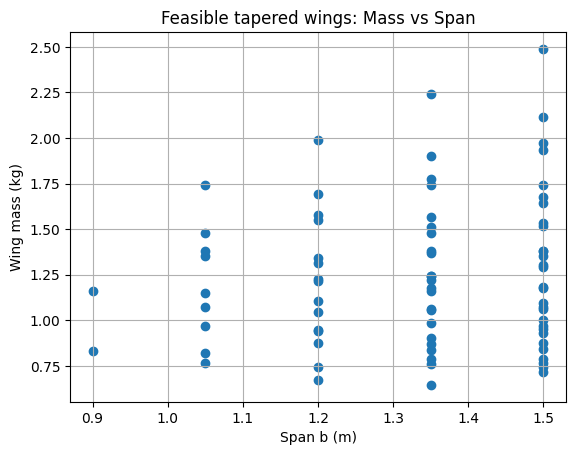

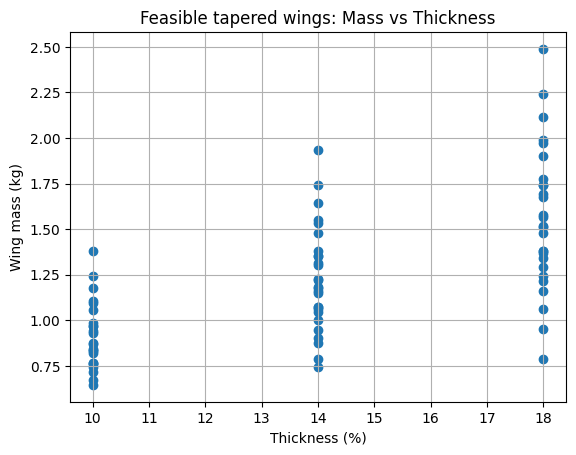

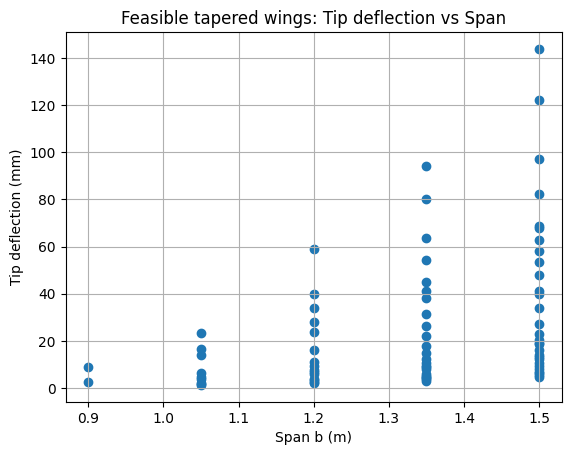

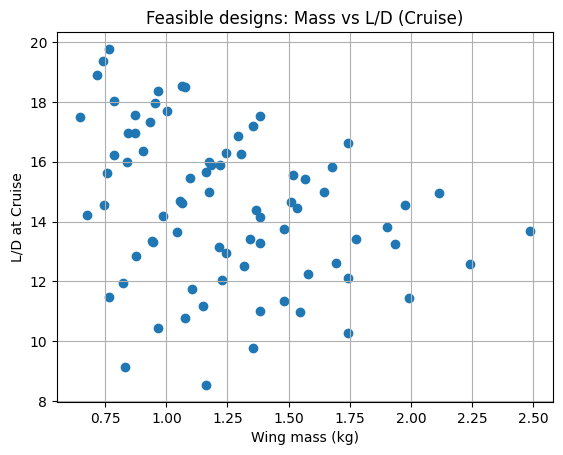

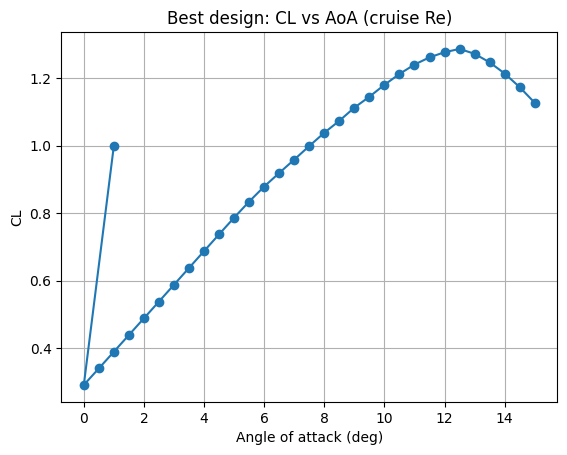

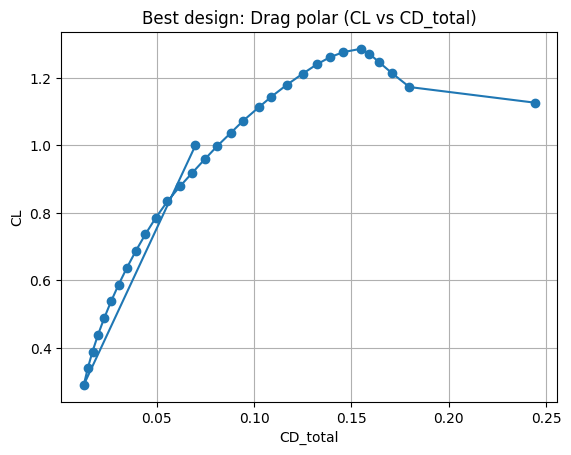

In [4]:
result = optimize_wing(
    mass_kg=3.0,
    v_cruise=18.0,
    v_loiter=14.0,
    make_plots=True
)

In [5]:
print("Aspect Ratio:", result["aspect_ratio"])
print("Wing Mass Fraction:", result["wing_mass"] / result["mass_kg"])
print("Tip Deflection Ratio:", result["delta_tip"] / result["b"])

Aspect Ratio: 6.35294117647059
Wing Mass Fraction: 0.21515624999999997
Tip Deflection Ratio: 0.05948651618437498
